# **Resolvendo identificação de sonolência com o MNIST**
<font size=3>

Vamos resolver uma tarefa de classificação usando um dataset com 41 mil fotos de pessoas classificados em "Drowsy" (sonolento) e "Non-Drowsy" (não sonolento).


### **_Fluxo de trabalho utilizado para esse projeto (Deep Learning):_**
<font size=3>

Para *modelar* e avaliar corretamente a rede neural, vou seguir os seguintes passos de **fluxo de trabalho**:
1. **Importação e análise exploratória dos dados**;
2. **Pré-processamento dos dados**;
3. **Modelagem e compilação do modelo**;
4. **Treinamento validativo**;
5. **Treinamento final**;
6. **Avaliação do modelo**;
7. **Salvar o modelo**.


In [3]:
# Bibliotecas principais do projeto

import numpy as np          # operações matemáticas e manipulação de arrays
import tensorflow as tf     # framework de deep learning
import matplotlib.pyplot as plt  # visualização de gráficos e imagens
import os                   # gerenciamento de pastas e arquivos
import random               # embaralhamento dos dados
from PIL import Image       # leitura e processamento das imagens
from sklearn.model_selection import train_test_split  # divisão dos dados
from keras import Input, layers, Model  # construção da rede neural
import kagglehub             # download do dataset do Kaggle

### **1. Importação e análise exploratória dos dados:**
<font size=3>


Começo o projeto, importando o dataset [Driver Drowsiness](https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/) da plataforma Kaggle.

In [4]:
 # Faz o download do dataset e retorna o caminho local onde foi salvo

path = kagglehub.dataset_download("ismailnasri20/driver-drowsiness-dataset-ddd")
print("Caminho para os arquivos do dataset:", path)

100%|██████████| 2.58G/2.58G [00:35<00:00, 78.0MB/s]

Extracting files...


Caminho para os arquivos do dataset: /root/.cache/kagglehub/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/versions/1


In [5]:
# Percorre as pastas do dataset para entender sua estrutura
# equivalente ao print(X_train.shape) do MNIST, serve para conhecer os dados antes de usar

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    if level < 3:
        imgs = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/  ({len(imgs)} imagens)")

1/  (0 imagens)
  Driver Drowsiness Dataset (DDD)/  (0 imagens)
    Drowsy/  (22348 imagens)
    Non Drowsy/  (19445 imagens)


In [6]:
# Caminho da pasta raiz que contém as subpastas 'Drowsy' e 'Non Drowsy'

main_path = os.path.join(path, 'Driver Drowsiness Dataset (DDD)')

# Monta a lista de caminhos completos de cada imagem por classe
# os.listdir retorna os nomes dos arquivos; os.path.join monta o caminho completo

drowsy_paths     = [os.path.join(main_path, 'Drowsy',     p) for p in os.listdir(os.path.join(main_path, 'Drowsy'))]
non_drowsy_paths = [os.path.join(main_path, 'Non Drowsy', p) for p in os.listdir(os.path.join(main_path, 'Non Drowsy'))]

print(f"Drowsy:     {len(drowsy_paths)} imagens")
print(f"Non Drowsy: {len(non_drowsy_paths)} imagens")

Drowsy:     22348 imagens
Non Drowsy: 19445 imagens


In [7]:
# Junta todos os caminhos e cria os rótulos correspondentes
# 0 = Drowsy (sonolento)
# 1 = Non Drowsy (acordado)

all_dirs   = drowsy_paths + non_drowsy_paths
all_labels = [0] * len(drowsy_paths) + [1] * len(non_drowsy_paths)

# Primeira divisão: 70% treino e 30% temporário (val + teste)
# stratify garante que a proporção entre as classes seja mantida

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_dirs,
    all_labels,
    test_size=0.30,
    random_state=42,
    stratify=all_labels
)

# Segunda divisão: dos 30% restantes, 2/3 para validação e 1/3 para teste
# 70% treino, 20% validação, 10% teste

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=1/3,
    random_state=42,
    stratify=temp_labels
)

print(f"\nTotal de imagens:      {len(all_dirs)}")
print(f"Conjunto de treino:    {len(train_paths)} imagens")
print(f"Conjunto de validação: {len(val_paths)} imagens")
print(f"Conjunto de teste:     {len(test_paths)} imagens")

# Exibe a distribuição das classes
# confirma que o stratify funcionou
print("\nDistribuição das classes:")
print(f"Treino    - Drowsy: {train_labels.count(0)} | Non Drowsy: {train_labels.count(1)}")
print(f"Validação - Drowsy: {val_labels.count(0)} | Non Drowsy: {val_labels.count(1)}")
print(f"Teste     - Drowsy: {test_labels.count(0)} | Non Drowsy: {test_labels.count(1)}")


Total de imagens:      41793
Conjunto de treino:    29255 imagens
Conjunto de validação: 8358 imagens
Conjunto de teste:     4180 imagens

Distribuição das classes:
Treino    - Drowsy: 15644 | Non Drowsy: 13611
Validação - Drowsy: 4469 | Non Drowsy: 3889
Teste     - Drowsy: 2235 | Non Drowsy: 1945


In [8]:
# Resolução de cada imagem redimensionada (32×32)

IMG_SIZE = (32, 32)

# Limite de imagens carregadas por classe

MAX_POR_CLASSE = 5000

# Extrai o nome da classe a partir do caminho da imagem

def extract_class_name(p):
    return os.path.basename(os.path.dirname(p))

print(extract_class_name(train_paths[0]))
print(extract_class_name(train_paths[2]))
print(extract_class_name(train_paths[3]))
print(extract_class_name(train_paths[6]))

Non Drowsy
Drowsy
Drowsy
Non Drowsy


In [9]:
# Carrega imagens, converte para escala de cinza
# Retorna X (pixels) e y (rótulos) como arrays numpy
# X_train com as imagens e y_train com os rótulos, pronto para o pré-processamento

def load_images(paths):
    X, y = [], []
    drowsy_count, non_drowsy_count = 0, 0

    for p in paths:
        classe = extract_class_name(p)

        # Pula se já atingiu o limite da classe
        if classe == 'Drowsy'     and drowsy_count     >= MAX_POR_CLASSE: continue
        if classe == 'Non Drowsy' and non_drowsy_count >= MAX_POR_CLASSE: continue

        # Abre a imagem e converte para escala de cinza
        img = Image.open(p).convert('L')

        # Redimensiona para 32×32
        img = img.resize(IMG_SIZE)

        # Guarda como matriz 32×32 (reshape no pré-processamento)
        X.append(np.array(img))

        y.append(0 if classe == 'Drowsy' else 1)

        if classe == 'Drowsy': drowsy_count     += 1
        else:                  non_drowsy_count += 1

    return np.array(X), np.array(y)

In [10]:
# Carrega os três conjuntos (equivalente ao mnist.load_data())

X_train, y_train = load_images(train_paths)
X_val,   y_val   = load_images(val_paths)
X_test,  y_test  = load_images(test_paths)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (10000, 32, 32), y_train: (10000,)
X_test:  (4180, 32, 32),  y_test:  (4180,)


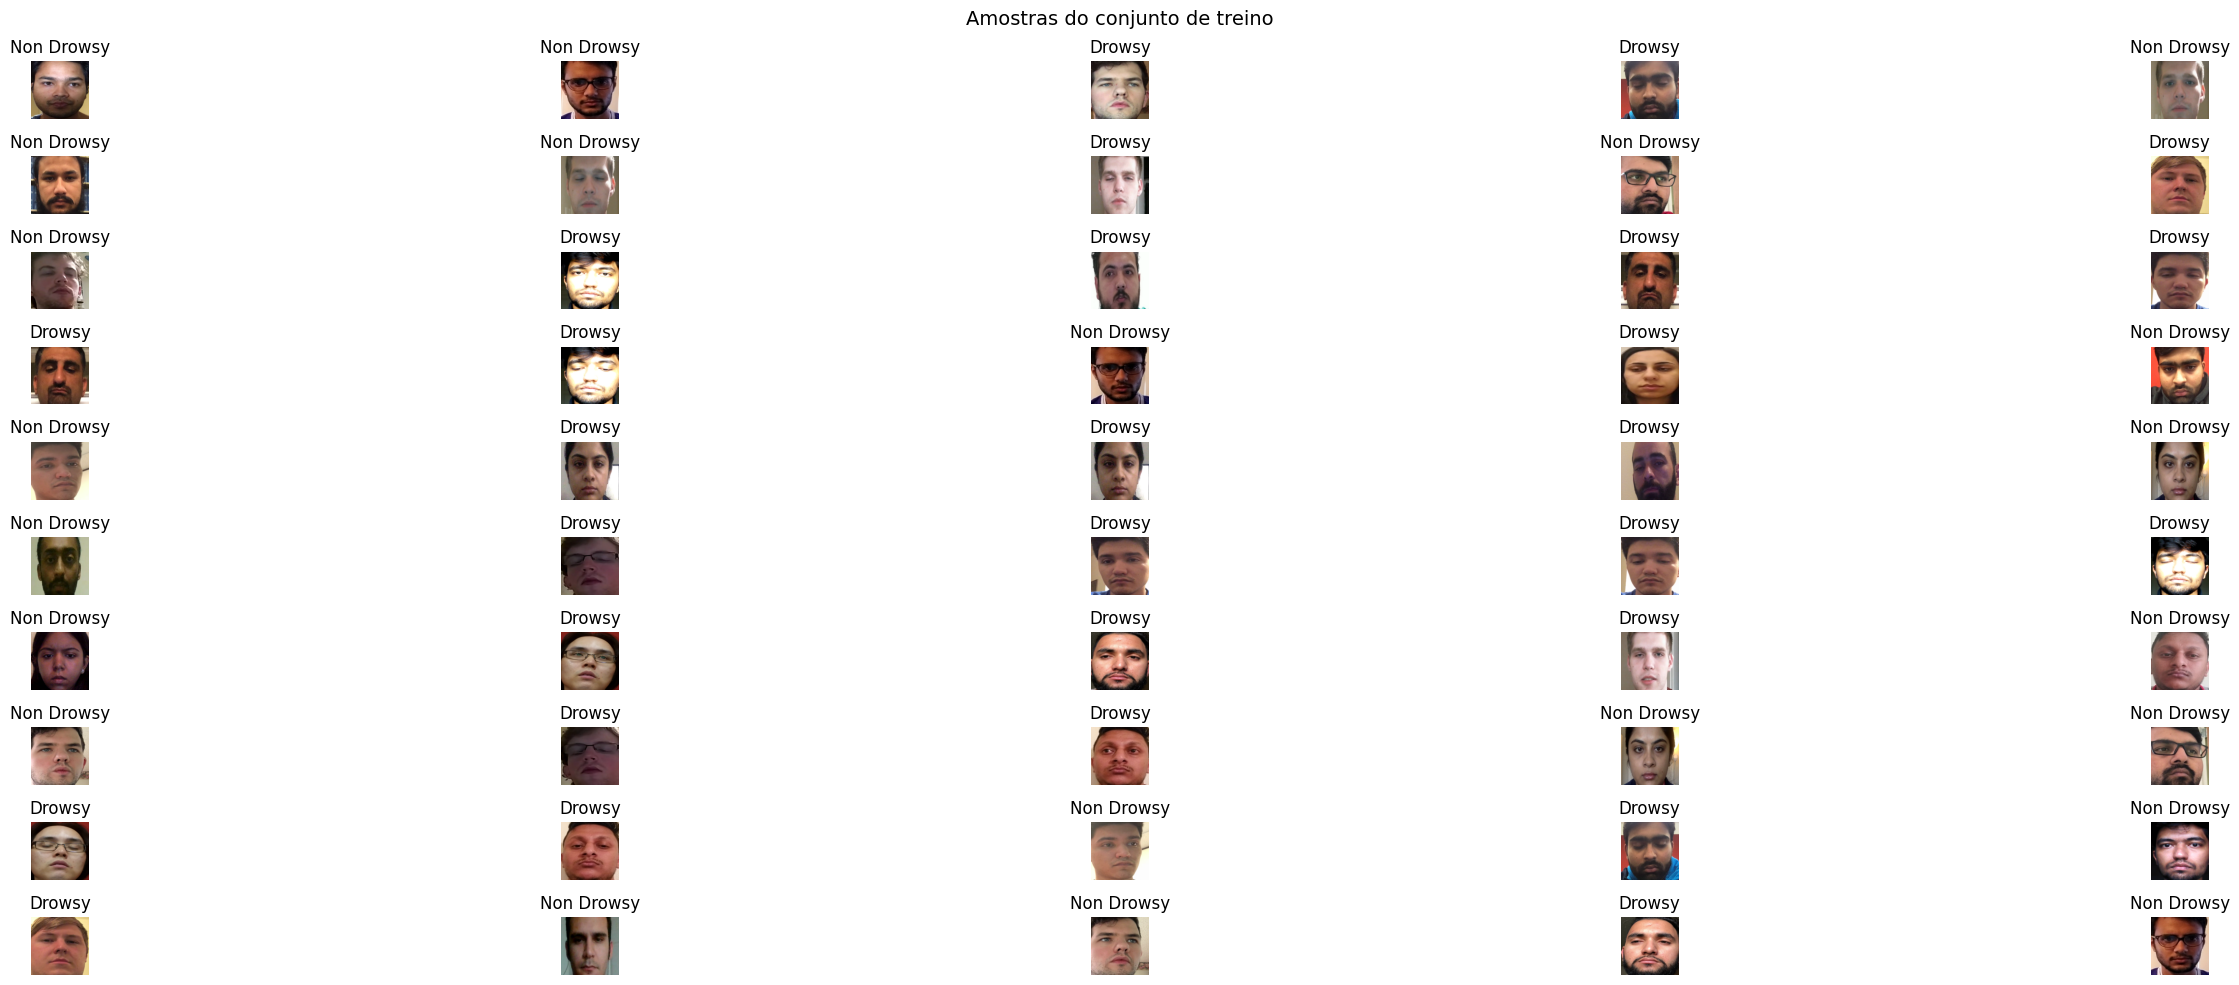

In [11]:
# Exibe uma grade com 50 amostras do conjunto de treino e seus rótulos

def show_images_with_labels(paths, num_images=50):
    plt.figure(figsize=(30, 10))
    for i, p in enumerate(paths[:num_images]):
        img   = Image.open(p)
        label = extract_class_name(p)
        plt.subplot(10, 5, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
    plt.suptitle('Amostras do conjunto de treino', fontsize=14)
    plt.tight_layout()
    plt.show()

show_images_with_labels(train_paths, num_images=50)

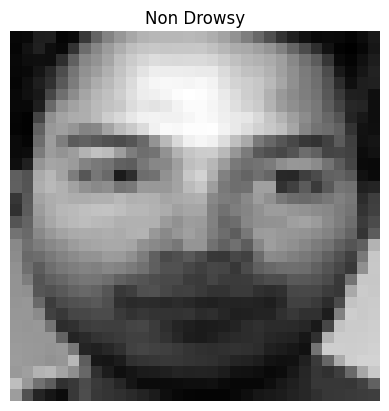

In [12]:
# Visualiza a primeira imagem do treino — equivalente ao plt.imshow(X_train[0]) do MNIST
plt.imshow(X_train[0], cmap='gray')
plt.title('Drowsy' if y_train[0] == 0 else 'Non Drowsy')
plt.axis('off')
plt.show()

In [13]:
# Verifica os valores mínimo e máximo dos pixels antes de normalizar

print("Min:", X_train.min(), "Max:", X_train.max())

Min: 0 Max: 255


### **2. Pré-processamento dos dados:**

In [14]:
# Converte os pixels para float32 — formato numérico exigido pelo TensorFlow

X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

# Captura as dimensões > N = amostras, width = largura (32)

N_train, width, _ = X_train.shape
N_val,   _,    _ = X_val.shape
N_test,  _,    _ = X_test.shape

# Normalização: divide todos os pixels pelo valor máximo de pixels (255)
# coloca os valores no intervalo [0, 1]

Max = X_train.max()

X_train /= Max
X_val   /= Max
X_test  /= Max

# Achatando as matrizes em vetores de 1024 valores para a camada dense:
X_train = X_train.reshape((N_train, width * width))
X_val   = X_val.reshape((N_val,   width * width))
X_test  = X_test.reshape((N_test,  width * width))

# Definir quantos neurônios a camada vai ter (1 por pixel)
input_size = X_train.shape[1]
print("Tamanho da entrada:", input_size)

Tamanho da entrada: 1024


In [15]:
# Codificação one-hot:
# depth=2 (Drowsy e Non Drowsy)

y_train = tf.one_hot(y_train, depth=2)
y_val   = tf.one_hot(y_val,   depth=2)
y_test  = tf.one_hot(y_test,  depth=2)

# Transforma o número inteiro em um vetor de probabilidades
print("Exemplo de rótulo one-hot:", y_train[0].numpy())


Exemplo de rótulo one-hot: [0. 1.]


### **3. Modelagem e compilação do modelo:**

In [16]:
# Camada de entrada: recebe um vetor de 1.024 valores (um por pixel)
x_in = Input(shape=(input_size,))

# Camada oculta 1: 128 neurônios
# Zera valores negativos e mantém os positivos
x = layers.Dense(128, activation="relu")(x_in)
x = layers.Dense(64, activation="relu")(x)


# Camada de saída: 2 neurônios (um por classe) com softmax
# softmax transforma as saídas em probabilidades que somam 1
x_out = layers.Dense(2, activation="softmax")(x)

# Modelo conectando engtrada e saída
model = Model(inputs=x_in, outputs=x_out)

# Exibe número de paramêtros por camada
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,586 (545.26 KB)

 Trainable params: 139,586 (545.26 KB)

 Non-trainable params: 0 (0.00 B)

<font size=3>
<br>
    
Agora, iremos definir o **otimizador**, **função de custo**, e a **métrica** para os dados de validação.

In [17]:
# acc: métrica de acurácia monitorada a cada época
model.compile(optimizer="Adam", loss="categorical_crossentropy", metrics=['acc'])

### **4. Treinamento validativo:**
<font size=3>

Este é o momento que validamos a modelagem da rede neural do passo anterior. Verificamos as curvas de **treinamento** e **validação** a fim de identificar se nosso modelo está **bem ajustado**, ou sofre de **_overfitting_** ou **_underfitting_**. Caso a validação não mostre um bom desempenho, devemos voltar ao passo anterior para aprimorar a rede neural — por exemplo, alterando o número de neurônios e camadas (*hiperparâmetros*) — e **reiniciar e executar todo o código**.

**Observação:** Os dados de **validação** já foram separados previamente, por isso usamos `validation_data` em vez de `validation_split`.

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - acc: 0.9975 - loss: 0.0073 - val_acc: 0.9944 - val_loss: 0.0169
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9945 - loss: 0.0165 - val_acc: 0.9963 - val_loss: 0.0136
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.9988 - loss: 0.0045 - val_acc: 0.9982 - val_loss: 0.0103
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.9994 - loss: 0.0026 - val_acc: 0.9977 - val_loss: 0.0107
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 1.0000 - loss: 5.1389e-04 - val_acc: 0.9988 - val_loss: 0.0053
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.9916 - loss: 0.0250 - val_acc: 0.9966 - val_loss: 0.0152
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9970 - loss: 0.0103 - val_acc: 0.9976 - val_loss: 0.0065
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9988 - loss: 0.0036 - val_acc: 0.9978 - val_loss: 0.0083
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

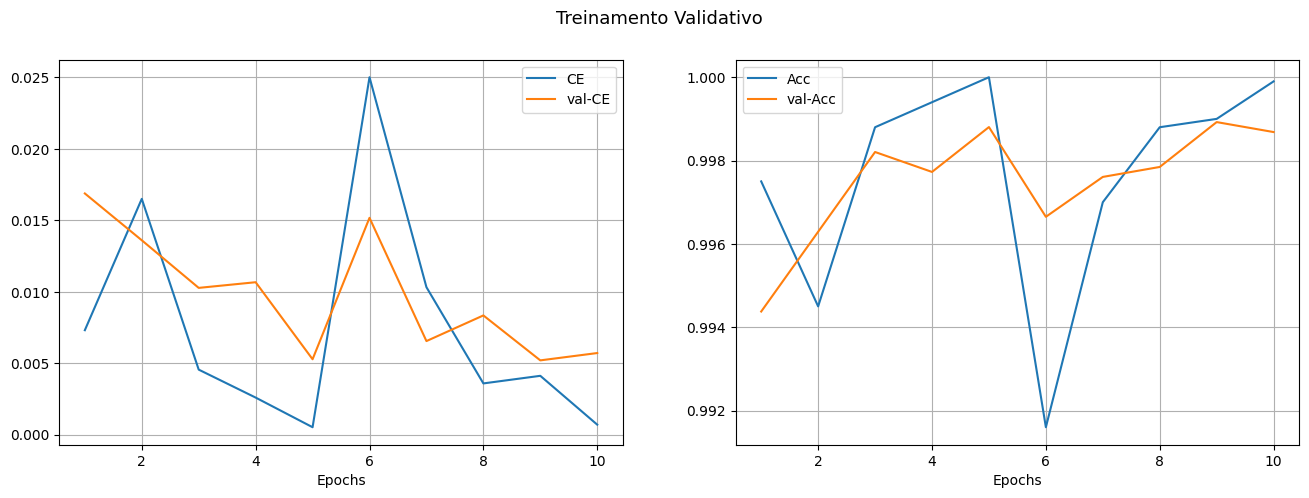

In [24]:
# False → treinamento validativo (analisa as curvas antes de treinar de verdade)
# True  → treinamento final (treina com todos os dados após validar o modelo)

final_training = False

n_epochs   = 10  # número de vezes que o modelo vê todos os dados de treino
batch_size = 32  # quantidade de imagens processadas por vez antes de atualizar os pesos

if not final_training:

    # Treina o modelo usando X_val e y_val para monitorar a generalização
    # se as curvas de treino e validação ficarem próximas, o modelo está bem ajustado
    report = model.fit(
        x=X_train, y=y_train,
        validation_data=(X_val, y_val),
        epochs=n_epochs,
        batch_size=batch_size
    )

    # Extrai as métricas a cada época

    loss     = report.history['loss']
    acc      = report.history['acc']
    val_loss = report.history['val_loss']
    val_acc  = report.history['val_acc']

    epochs = np.linspace(1, len(loss), len(loss))

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    # Curva de loss: quanto menor, melhor
    # se val_loss subir enquanto loss desce = overfitting
    ax[0].plot(epochs, loss,     label='CE')
    ax[0].plot(epochs, val_loss, label='val-CE')

    # Curva de acurácia: quanto maior, melhor
    # curvas próximas = boa generalização
    ax[1].plot(epochs, acc,     label='Acc')
    ax[1].plot(epochs, val_acc, label='val-Acc')

    for i in range(2):
        ax[i].set_xlabel("Epochs")
        ax[i].legend()
        ax[i].grid()

    plt.suptitle('Treinamento Validativo', fontsize=13)
    plt.show()

As curvas mostram um modelo bem ajustado com alguns pontos de atenção:

**Loss (CE):** ambas as curvas caem ao longo das épocas, o que é o comportamento esperado. O pico na época 6 é normal, pois é o modelo "tropeçando" antes de se ajustar melhor. **O importante é que val-CE acompanha CE sem subir enquanto CE desce, o que descartaria overfitting.**

**Acurácia:** as duas curvas ficam entre 99,2% e 100%, **sempre próximas uma da outra.** Isso confirma que o modelo generaliza bem, aprende nos dados de treino e mantém o desempenho nos dados de validação que nunca viu.

### **5. Treinamento final:**
<font size=3>

Com a nossa rede bem modelada, agora, faremos o treinamento do modelo final, *juntando* os dados de treinamento e validação.

In [25]:
if final_training:

    # Treina com todos os dados de treino sem separar validação
    # usado após confirmar que o modelo está bem ajustado na fase anterior
    report = model.fit(x=X_train, y=y_train, epochs=n_epochs, batch_size=batch_saize)

    # plotando as métricas ao longo das épocas:
    loss = report.history['loss']
    acc = report.history['acc']

    epochs = np.linspace(1, len(loss), len(loss))

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    ax[0].plot(epochs, loss, c='tab:blue')
    ax[1].plot(epochs, acc, c='tab:orange')

    ax[0].set_ylabel('CE')
    ax[1].set_ylabel('Acc')

    for i in range(2):
        ax[i].set_xlabel("Epochs")
        ax[i].grid()

    plt.show()


### **6. Avaliação do modelo:**
<font size=3>

Avaliando o modelo com os dados de teste.

In [20]:
if final_training:
    # Avalia o modelo nos dados de teste — nunca vistos durante o treino
    # retorna a função de custo (CE) e a acurácia final

    ce, acc = model.evaluate(x=X_test, y=y_test, batch_size=batch_size)
    print(f"\nCE = {ce:.4f}, acc = {acc:.4f}\n")

131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Matriz de Confusão:
[[2232    3]
 [   2 1943]]


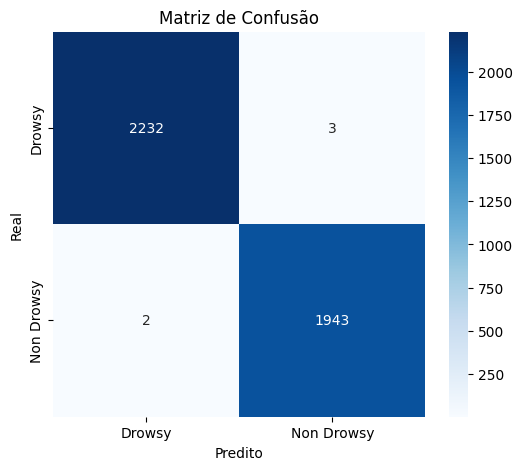


Relatório de Classificação:
              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      2235
  Non Drowsy       1.00      1.00      1.00      1945

    accuracy                           1.00      4180
   macro avg       1.00      1.00      1.00      4180
weighted avg       1.00      1.00      1.00      4180



In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predições do modelo
y_pred = model.predict(X_test)

# Converte de one-hot para rótulos (0 ou 1)
y_true = np.argmax(y_test.numpy(), axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred_classes)

print("\nMatriz de Confusão:")
print(cm)

# Plot da matriz de confusão
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Drowsy', 'Non Drowsy'],
    yticklabels=['Drowsy', 'Non Drowsy']
)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# Precision, Recall e F1-score
print("\nRelatório de Classificação:")
print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=['Drowsy', 'Non Drowsy']
    )
)

- 2232 sonolentos identificados corretamente — só 3 passaram despercebidos
- 1943 acordados identificados corretamente — só 2 foram alarmes falsos
- Total de erros: apenas 5 em 4.180 imagens

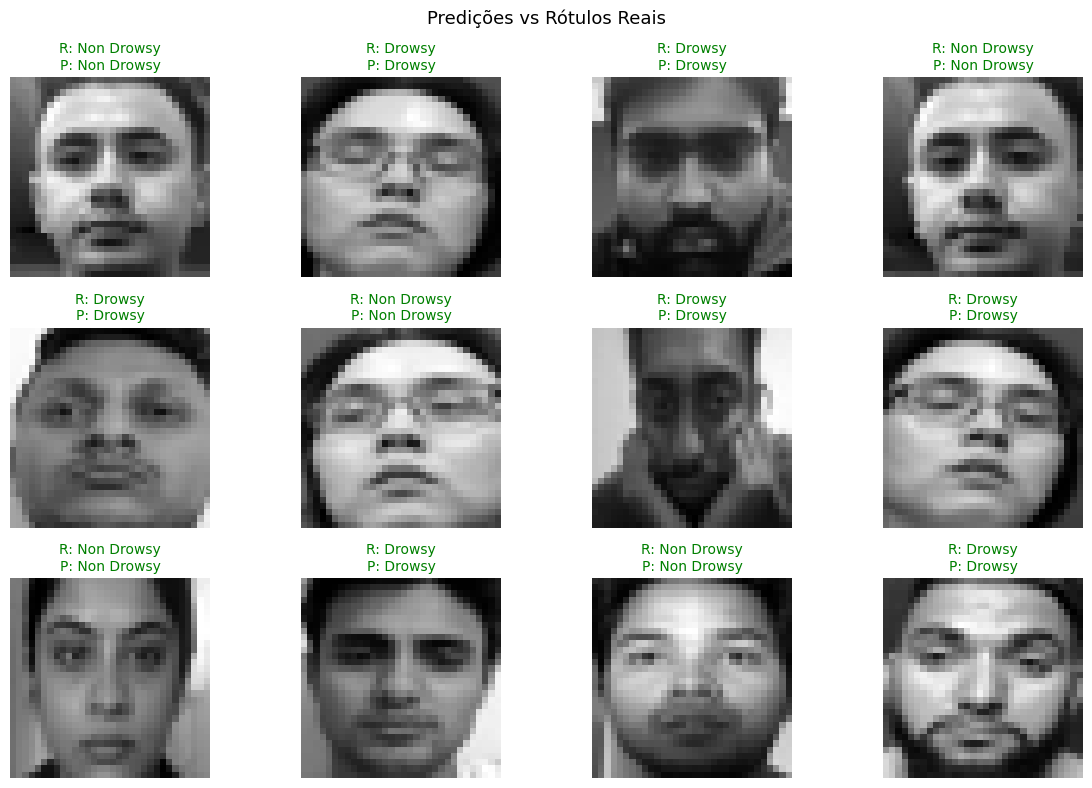

In [28]:
# Exibe as 12 primeiras predições com a imagem, rótulo real e rótulo predito
# útil para verificar visualmente onde o modelo acerta e onde erra
classes = ['Drowsy', 'Non Drowsy']

plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i].reshape(IMG_SIZE), cmap='gray')

    real = classes[np.argmax(y_test[i])]
    pred = classes[np.argmax(y_pred[i])]

    # Título verde se acertou, vermelho se errou
    cor = 'green' if real == pred else 'red'
    plt.title(f"R: {real}\nP: {pred}", fontsize=10, color=cor)
    plt.axis('off')

plt.suptitle('Predições vs Rótulos Reais', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
# Salva o modelo treinado em formato .keras para uso posterior
#model.save('modelo_sonolencia.keras')
#print("Modelo salvo com sucesso!")

# Faz o download do arquivo para o computador local
#from google.colab import files
#files.download('modelo_sonolencia.keras')